# CME Futures: Temporal Feature Engineering

This notebook fits time-series models inside walk-forward CV folds and
extracts temporal features for downstream ML models. Three model families
are applied to the CME futures carry signal:

1. **ARIMA**: Mean-reversion forecasts of carry z-score per product
2. **FFT/Spectral**: Seasonal cycle detection in carry percentage
3. **HMM Regimes**: Portfolio-level carry regime switching

**Learning Objectives**:
- Fit ARIMA on a slowly mean-reverting signal (carry z-score) within
  walk-forward folds to avoid look-ahead bias
- Extract spectral features (dominant period, seasonal energy) from
  rolling FFT applied to carry dynamics
- Use filtered (not smoothed) HMM probabilities for regime features
- Combine temporal features with Ch8 cross-sectional features

**Book Reference**: Chapter 9, Sections 9.3-9.5

**Prerequisites**: [`02_labels`](02_labels.ipynb) (prices, CV config) and
`03_financial_features.py` (carry features for reference).

In [1]:
"""CME Futures: Temporal Feature Engineering."""

import multiprocessing
import re
import warnings
from datetime import date

# Pin the multiprocessing start method to fork before any pool-using import
# (statsforecast.StatsForecast ships its own loky-based Pool that respects
# this). Forkserver/spawn — Python 3.14's defaults — would re-execute this
# script in each worker without an `if __name__ == "__main__":` guard.
if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

import numpy as np
import pandas as pd
import polars as pl
from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import KMeans
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

from data import load_cme_futures
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
PRIMARY_LABEL = "fwd_ret_5d"
MAX_PRODUCTS = 0  # 0 = all products; >0 limits ARIMA/HMM/FFT to N products
FFT_WINDOW = 252  # FFT window (trading days)

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"
STRATEGY_ID = CASE_STUDY_ID

# Product-to-sector mapping
PRODUCT_GROUPS = {
    "equity_index": ["ES", "NQ", "YM", "RTY"],
    "treasuries": ["ZN", "ZB", "ZF", "ZT"],
    "energy": ["CL", "NG", "HO", "RB"],
    "metals": ["GC", "SI", "HG", "PL"],
    "currencies": ["6E", "6J", "6B", "6A", "6C", "6S"],
    "agriculture": ["ZC", "ZS", "ZW", "ZM", "ZL"],
    "livestock": ["LE", "HE", "GF"],
}
ALL_PRODUCTS = [p for products in PRODUCT_GROUPS.values() for p in products]

if MAX_PRODUCTS > 0:
    ARIMA_PRODUCTS = ALL_PRODUCTS[:MAX_PRODUCTS]
else:
    ARIMA_PRODUCTS = ALL_PRODUCTS

## 1. Load Data and Resolve the Fold Contract

Load prices from Ch7 output, then resolve the walk-forward boundaries **before
any model is fitted**. Every fit below is sealed against these boundaries, so
they have to exist first.

The folds are derived from the label frame, not the price frame. The consumer
side (`load_modeling_dataset`) derives them from the label frame too, and the
two indexes are not the same: the label parquet starts later than the prices
because the forward return needs a window to resolve. Deriving both sides from
the same frame is what makes the `fold` ids in this artifact mean the same
thing downstream as they do here.

In [4]:
# Load raw data and compute carry
df = load_cme_futures().rename({"session_date": "timestamp", "tenor": "position"})

if MAX_PRODUCTS > 0:
    df = df.filter(pl.col("product").is_in(ARIMA_PRODUCTS))

print(f"Loaded {len(df):,} rows, {df['product'].n_unique()} products")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 312,859 rows, 30 products
Date range: 2011-01-03 to 2025-12-31


In [5]:
SETUP = load_setup_config(CASE_STUDY_ID)
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
LABEL_HORIZON_SESSIONS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))

label_frame = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
splits = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


# The holdout seal for the supervised screen in section 8 binds on the outcome
# endpoint, not the decision date: a decision carrying a 5-session forward return
# is realized 5 sessions later. Sessions come from the traded calendar in the
# data, never from a literal.
HOLDOUT_START = _as_date(load_evaluation_config(CASE_STUDY_ID)["holdout_start"])
_sessions = df.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
_pre_holdout = [d for d in _sessions if d < HOLDOUT_START]
LAST_SEALED_DECISION_DATE = _pre_holdout[-(LABEL_HORIZON_SESSIONS + 1)]

print(f"CV splits: {len(splits)} folds  (label buffer {LABEL_BUFFER})")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {s['train_start']} → {s['train_end']}, "
        f"val {s['val_start']} → {s['val_end']}"
    )
print(f"Holdout opens {HOLDOUT_START}; last sealed decision date {LAST_SEALED_DECISION_DATE}")

CV splits: 5 folds  (label buffer 5D)
  Fold 0: train 2015-01-05 00:00:00 → 2022-12-22 00:00:00, val 2023-01-03 00:00:00 → 2023-12-21 00:00:00
  Fold 1: train 2014-01-03 00:00:00 → 2021-12-23 00:00:00, val 2022-01-03 00:00:00 → 2022-12-30 00:00:00
  Fold 2: train 2013-01-01 00:00:00 → 2020-12-24 00:00:00, val 2021-01-05 00:00:00 → 2021-12-31 00:00:00
  Fold 3: train 2012-01-04 00:00:00 → 2019-12-26 00:00:00, val 2020-01-06 00:00:00 → 2021-01-04 00:00:00
  Fold 4: train 2011-01-05 00:00:00 → 2018-12-26 00:00:00, val 2019-01-04 00:00:00 → 2020-01-03 00:00:00
Holdout opens 2024-01-01; last sealed decision date 2023-12-21


## 2. Compute Carry for Temporal Modeling

We recompute carry from raw prices rather than loading `features/financial.parquet`
from `03_financial_features.py`. **Rationale**: temporal models need the carry time-series
in product-date form (not the position-expanded feature matrix), and the
computation is lightweight. This keeps the temporal notebook self-contained:
`03_financial_features` and `04_model_based_features` are **parallel branches** that merge
downstream in Chapter 11. Both start from the same raw data and produce independent feature
sets. The carry formula is identical (annualized front-deferred spread), and the
z-score uses a 63d window matching `carry_zscore_63d` in `03_financial_features`.

In [6]:
def compute_carry(data: pl.DataFrame) -> pl.DataFrame:
    """Compute carry percentage from front and deferred month prices."""
    # Raw (unadjusted) close: the term-structure spread must read contemporaneous
    # tenor levels, not the ratio-adjusted series whose levels encode roll history.
    # This makes the module's stated rationale ("recompute carry from raw prices")
    # literally true — before, it loaded the adjusted panel and computed on close.
    front = (
        data.filter(pl.col("position") == 0)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c0_price"})
    )
    second = (
        data.filter(pl.col("position") == 1)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c1_price"})
    )

    carry_df = front.join(second, on=["product", "timestamp"], how="inner")
    carry_df = carry_df.with_columns(
        ((pl.col("c0_price") - pl.col("c1_price")) / pl.col("c0_price") * 12).alias("carry_pct")
    )

    # Smoothed carry and z-score
    carry_df = carry_df.sort(["product", "timestamp"])
    carry_df = carry_df.with_columns(
        pl.col("carry_pct").rolling_mean(window_size=21).over("product").alias("carry_21d"),
    )
    carry_df = carry_df.with_columns(
        (
            (pl.col("carry_21d") - pl.col("carry_21d").rolling_mean(63).over("product"))
            / pl.col("carry_21d").rolling_std(63).over("product").clip(lower_bound=1e-6)
        )
        .clip(lower_bound=-5.0, upper_bound=5.0)
        .alias("carry_zscore_63d")
    )

    return carry_df.select(
        ["product", "timestamp", "carry_pct", "carry_21d", "carry_zscore_63d"]
    ).drop_nulls()


carry = compute_carry(df)
print(f"Carry data: {len(carry):,} product-dates")

Carry data: 108,980 product-dates


---

## 3. ARIMA on Carry Z-Score

The carry signal is slowly mean-reverting (term structure changes gradually).
ARIMA(p,0,q) captures the predictable component of carry z-score.
Parameters are selected by AICc within a [0,3] x [0,3] grid.

**Walk-forward discipline**: For each CV fold we run a single
`StatsForecast.cross_validation` (`h=1`, `step_size=1`, `refit=21`) over the
fold window. Every ARIMA value it emits — for the later training dates and the
test window alike — is an **out-of-sample 1-step-ahead forecast**: the value at
date t is predicted from data strictly earlier than t, with the (p,0,q) order
re-selected by AICc every 21 steps. There are no in-sample fitted values; the
walk simply begins after the `burnin=252` warm-up. This produces causal
features across each fold, which downstream per-fold CV requires.

### Run ARIMA Per Fold (Multi-Series Walk-Forward)

For each CV fold we bundle every product into a single long-format frame
(`unique_id=product`, `ds=date`, `y=carry_zscore_63d`) and call
`StatsForecast.cross_validation` once. The library produces 1-step-ahead OOS
forecasts for every (product, date) inside the test window of the CV, with
`refit=21` re-selecting (p,d,q) per series via AICc every 21 steps and
`n_jobs=-1` distributing series across CPU cores. This is the same
walk-forward primitive used by `09_model_based_features/10_uncertainty_features`
— single canonical pattern across the book. The first `burnin=252` rows of
each product's in-fold history form the warm-up for the initial fit and
receive NaN features.

In [7]:
import time

ARIMA_BURNIN = 252
ARIMA_REFIT_FREQ = 21

arima_results = []
arima_t0 = time.time()

_carry_ts_dtype = carry.schema["timestamp"]


def _date_lit(value) -> pl.Expr:
    """Cast a Python date/timestamp to the carry frame's timestamp dtype.

    The carry loader returns `pl.Date` today, so this is a no-op cast; it
    asserts the bound dtype matches the column dtype. If a downstream loader
    promotes `timestamp` to `pl.Datetime`, the upper-bound usage at the
    fold filter would need to switch to a next-day-exclusive sentinel
    (`+ pd.Timedelta(days=1)` with `<` comparison) — left as a follow-up.
    """

    return pl.lit(pd.Timestamp(value).date()).cast(_carry_ts_dtype)


for fold_idx, split in enumerate(splits):
    train_start = pd.Timestamp(split["train_start"]).date()
    train_end = pd.Timestamp(split["train_end"]).date()
    test_start = pd.Timestamp(split["val_start"]).date()
    test_end = pd.Timestamp(split["val_end"]).date()

    print(
        f"\nFold {fold_idx}: train {train_start}→{train_end}, test {test_start}→{test_end}",
        flush=True,
    )

    # Build long-format input for all products in this fold
    in_window = (
        carry.filter(pl.col("product").is_in(ARIMA_PRODUCTS))
        .filter(
            (pl.col("timestamp") >= _date_lit(split["train_start"]))
            & (pl.col("timestamp") <= _date_lit(split["val_end"]))
        )
        .drop_nulls(subset=["carry_zscore_63d"])
        .sort(["product", "timestamp"])
    )
    series_lengths = in_window.group_by("product").len().sort("len")
    eligible = series_lengths.filter(pl.col("len") >= ARIMA_BURNIN + 30)["product"].to_list()
    if not eligible:
        print("  no eligible products for fold")
        continue
    in_window = in_window.filter(pl.col("product").is_in(eligible))

    # n_windows must be uniform across series; use min(series_length) - burnin so
    # every product walks forward over its last (length - burnin) rows.
    min_len = int(series_lengths.filter(pl.col("product").is_in(eligible))["len"].min())
    n_windows = min_len - ARIMA_BURNIN

    fold_input = pd.DataFrame(
        {
            "unique_id": in_window["product"].to_list(),
            "ds": pd.to_datetime(in_window["timestamp"].to_list()),
            "y": in_window["carry_zscore_63d"].to_numpy(),
        }
    )

    sf = StatsForecast(
        models=[AutoARIMA(season_length=1)],
        freq="B",
        n_jobs=-1,
    )
    cv = sf.cross_validation(
        df=fold_input,
        h=1,
        step_size=1,
        n_windows=n_windows,
        refit=ARIMA_REFIT_FREQ,
    )

    # Map results back per product, padding with NaN for the burn-in head
    cv_pl = pl.from_pandas(cv).rename({"unique_id": "product", "ds": "timestamp"})
    cv_pl = cv_pl.with_columns(pl.col("timestamp").cast(pl.Date))
    fold_df = (
        in_window.select(["product", "timestamp"])
        .join(
            cv_pl.select(["product", "timestamp", "AutoARIMA", "y"]),
            on=["product", "timestamp"],
            how="left",
        )
        .with_columns(
            arima_carry_forecast=pl.col("AutoARIMA"),
            arima_carry_residual=pl.col("y") - pl.col("AutoARIMA"),
            fold=pl.lit(fold_idx, dtype=pl.Int64),
        )
        .select(["timestamp", "product", "arima_carry_forecast", "arima_carry_residual", "fold"])
    )
    arima_results.append(fold_df)
    print(f"  {len(eligible)} products fitted, n_windows={n_windows}", flush=True)

arima_elapsed = time.time() - arima_t0


Fold 0: train 2015-01-05→2022-12-22, test 2023-01-03→2023-12-21


  30 products fitted, n_windows=1276



Fold 1: train 2014-01-03→2021-12-23, test 2022-01-03→2022-12-30


  30 products fitted, n_windows=1023



Fold 2: train 2013-01-01→2020-12-24, test 2021-01-05→2021-12-31


  30 products fitted, n_windows=766



Fold 3: train 2012-01-04→2019-12-26, test 2020-01-06→2021-01-04


  30 products fitted, n_windows=508



Fold 4: train 2011-01-05→2018-12-26, test 2019-01-04→2020-01-03


  30 products fitted, n_windows=251


In [8]:
if arima_results:
    arima_pl = pl.concat(arima_results)
    if arima_pl["timestamp"].dtype != pl.Date:
        arima_pl = arima_pl.with_columns(pl.col("timestamp").cast(pl.Date))
    print(
        f"\nARIMA total: {len(arima_pl):,} rows across "
        f"{arima_pl['product'].n_unique()} products, "
        f"{arima_pl['fold'].n_unique()} folds in {arima_elapsed:.0f}s"
    )
else:
    arima_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "arima_carry_forecast": pl.Float64,
            "arima_carry_residual": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No ARIMA results generated")


ARIMA total: 329,925 rows across 30 products, 5 folds in 1037s


---

## 4. FFT Spectral Features on Carry

Agriculture and energy futures have well-documented seasonal cycles.
We apply rolling FFT to carry percentage to extract:
- Dominant period (cycle length in days)
- Spectral energy at quarterly (~63d) and semi-annual (~126d) frequencies
- Spectral entropy (how concentrated the spectrum is)

Helper: compute FFT-derived statistics for a single rolling segment.

In [9]:
def _fft_window_features(segment: np.ndarray, target_periods: list[int]) -> dict[str, float]:
    centered = segment - segment.mean()
    fft_vals = np.fft.rfft(centered)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(len(segment))
    total_power = np.sum(power[1:])

    output = {
        "total_power": float(total_power),
        "dominant_period": float("nan"),
        "spectral_entropy": float("nan"),
    }
    for period in target_periods:
        output[f"energy_{period}d"] = float("nan")

    if len(power) <= 1 or total_power <= 0:
        return output

    dom_idx = np.argmax(power[1:]) + 1
    if freqs[dom_idx] > 0:
        output["dominant_period"] = float(1.0 / freqs[dom_idx])

    p_norm = power[1:] / total_power
    p_norm = p_norm[p_norm > 0]
    output["spectral_entropy"] = float(-np.sum(p_norm * np.log(p_norm)))

    for period in target_periods:
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs - target_freq))
        low_idx = max(1, freq_idx - 1)
        high_idx = min(len(power), freq_idx + 2)
        output[f"energy_{period}d"] = float(np.sum(power[low_idx:high_idx]) / total_power)
    return output

Compute rolling FFT features aligned with the original signal index.

In [10]:
def rolling_fft_features(
    signal: np.ndarray,
    window: int = 252,
    target_periods: list[int] | None = None,
) -> dict[str, np.ndarray]:
    if target_periods is None:
        target_periods = [63, 126]

    n = len(signal)
    spectral_energy = np.full(n, np.nan)
    dominant_period = np.full(n, np.nan)
    spectral_entropy = np.full(n, np.nan)
    freq_energies = {p: np.full(n, np.nan) for p in target_periods}

    for t in range(window, n):
        window_stats = _fft_window_features(signal[t - window : t], target_periods)
        spectral_energy[t] = window_stats["total_power"]
        dominant_period[t] = window_stats["dominant_period"]
        spectral_entropy[t] = window_stats["spectral_entropy"]
        for period in target_periods:
            freq_energies[period][t] = window_stats[f"energy_{period}d"]

    result = {
        "fft_spectral_energy": spectral_energy,
        "fft_dominant_period": dominant_period,
        "fft_spectral_entropy": spectral_entropy,
    }
    for period, energy in freq_energies.items():
        result[f"fft_energy_{period}d"] = energy
    return result

### Run FFT per product

Unlike ARIMA (which estimates coefficients) and HMM (which fits transition
matrices), FFT is a **deterministic transformation** with no fitted
parameters — there is nothing to overfit. The rolling window uses only
past data at each point, so walk-forward fitting is unnecessary.
This is the same discipline as any rolling feature (e.g., rolling mean).

In [11]:
fft_results = []

for product in ARIMA_PRODUCTS:
    prod_carry = (
        carry.filter(pl.col("product") == product)
        .sort("timestamp")
        .drop_nulls(subset=["carry_pct"])
    )
    if len(prod_carry) < FFT_WINDOW + 50:
        continue

    signal = prod_carry["carry_pct"].to_numpy()
    dates = prod_carry["timestamp"].to_list()

    fft_out = rolling_fft_features(signal, window=FFT_WINDOW, target_periods=[63, 126])

    prod_df = pl.DataFrame(
        {
            "timestamp": dates,
            "product": product,
            "fft_spectral_energy": fft_out["fft_spectral_energy"],
            "fft_dominant_period": fft_out["fft_dominant_period"],
            "fft_spectral_entropy": fft_out["fft_spectral_entropy"],
            "fft_energy_63d": fft_out["fft_energy_63d"],
            "fft_energy_126d": fft_out["fft_energy_126d"],
        }
    )
    fft_results.append(prod_df)
    valid_count = prod_df.drop_nulls(subset=["fft_spectral_energy"]).height
    print(f"  {product}: {valid_count} valid FFT observations")

  ES: 3782 valid FFT observations
  NQ: 3752 valid FFT observations


  YM: 3743 valid FFT observations


  RTY: 2049 valid FFT observations
  ZN: 3638 valid FFT observations


  ZB: 3659 valid FFT observations


  ZF: 3331 valid FFT observations
  ZT: 3239 valid FFT observations


...

  6J: 3735 valid FFT observations
  6B: 3707 valid FFT observations
  6A: 3753 valid FFT observations


  6C: 3727 valid FFT observations
  6S: 3340 valid FFT observations
  ZC: 3691 valid FFT observations


  ZS: 3691 valid FFT observations
  ZW: 3691 valid FFT observations
  ZM: 3691 valid FFT observations


  ZL: 3691 valid FFT observations
  LE: 3682 valid FFT observations
  HE: 3682 valid FFT observations


  GF: 3682 valid FFT observations


In [12]:
if fft_results:
    fft_base = pl.concat(fft_results)
    # Replicate per fold: FFT is deterministic (no fitted params), but downstream
    # per-fold join requires a fold column. Each fold gets the same FFT values,
    # so the materialised parquet is intentionally `n_folds×` larger than the
    # underlying FFT signal (e.g., ~110k unique (product, timestamp) rows ×
    # 5 folds = 545k rows). The redundancy is by design: it lets the per-fold
    # join contract stay uniform with ARIMA/HMM outputs (which DO vary by fold)
    # rather than introducing a special "broadcast" path for FFT alone.
    fft_pl = pl.concat([fft_base.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])
    print(
        f"\nFFT total: {len(fft_pl):,} rows, {fft_pl['product'].n_unique()} products, "
        f"{fft_pl['fold'].n_unique()} folds"
    )
else:
    fft_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "product": pl.String,
            "fft_spectral_energy": pl.Float64,
            "fft_dominant_period": pl.Float64,
            "fft_spectral_entropy": pl.Float64,
            "fft_energy_63d": pl.Float64,
            "fft_energy_126d": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No FFT results generated")


FFT total: 544,900 rows, 30 products, 5 folds


---

## 5. HMM Regime Detection on Portfolio Carry

A 2-state Gaussian HMM is fitted to the portfolio-level carry signal
(equal-weighted carry across all products). The states capture
"carry-favorable" vs "carry-unfavorable" macro regimes.

**Walk-forward**: For each fold, fit on training window, apply filtered
probabilities to train+test. Label switching is prevented by sorting states
by variance.

In [13]:
def fit_hmm_kmeans_init(X: np.ndarray, n_states: int = 2, random_state: int = 42) -> GaussianHMM:
    """Fit HMM with k-means-seeded initialization.

    K-means provides better starting points than random initialization,
    reducing sensitivity to EM local optima.
    """
    kmeans = KMeans(n_clusters=n_states, random_state=random_state, n_init=10)
    kmeans.fit(X)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=random_state,
        init_params="st",  # Only init startprob and transmat
    )

    # Set emission parameters from k-means
    model.means_ = kmeans.cluster_centers_
    model.covars_ = np.array(
        [np.cov(X[kmeans.labels_ == k].T).reshape(1, 1) + np.eye(1) * 1e-6 for k in range(n_states)]
    )

    model.fit(X)
    return model

Helper: enforce stable state labeling by sorting states on variance.

In [14]:
def sort_states_by_variance(model: GaussianHMM) -> np.ndarray:
    """Sort HMM states by variance (ascending) for consistent labeling."""
    variances = np.array([np.trace(model.covars_[k]) for k in range(model.n_components)])
    return np.argsort(variances)  # Low vol first

Helper: compute filtered probabilities via forward recursion (no look-ahead).

In [15]:
def compute_filtered_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm to avoid look-ahead bias inherent in
    smoothed (Viterbi/posterior) probabilities.

    Note: Uses ``model._compute_log_likelihood()`` (private API, hmmlearn >=0.3).
    If this breaks in a future version, replace with ``model.score_samples(X)``.
    """
    framelogprob = model._compute_log_likelihood(X)
    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    fwdlattice = np.zeros((n_samples, n_components))
    fwdlattice[0] = log_startprob + framelogprob[0]

    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    # Normalize to get probabilities
    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    log_probs = fwdlattice - log_normalizer
    return np.exp(log_probs)

### Compute Portfolio-Level Carry and Fit HMM per Fold

In [16]:
# Portfolio-level carry (equal-weighted across all products)
portfolio_carry = (
    carry.group_by("timestamp")
    .agg(
        pl.col("carry_pct").mean().alias("portfolio_carry"),
        pl.col("carry_21d").mean().alias("portfolio_carry_21d"),
    )
    .sort("timestamp")
    .drop_nulls()
)

print(f"Portfolio carry: {len(portfolio_carry):,} dates")

Portfolio carry: 3,792 dates


Helper: compute contiguous regime duration from most-likely state sequence.

In [17]:
def _regime_duration(test_states: np.ndarray) -> np.ndarray:
    duration = np.zeros(len(test_states))
    duration[0] = 1
    for t in range(1, len(test_states)):
        if test_states[t] == test_states[t - 1]:
            duration[t] = duration[t - 1] + 1
        else:
            duration[t] = 1
    return duration

Helper: fit one fold and return HMM features for train+test period.

In [18]:
def _fit_hmm_fold(portfolio_df: pl.DataFrame, split: dict[str, str], fold_idx: int):
    """Fit HMM on training data, forward-filter on train+test, return all probs."""
    train_start = pd.Timestamp(split["train_start"]).date()
    train_end = pd.Timestamp(split["train_end"]).date()
    test_start = pd.Timestamp(split["val_start"]).date()
    test_end = pd.Timestamp(split["val_end"]).date()

    train_carry = portfolio_df.filter(
        (pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= train_end)
    )
    test_carry = portfolio_df.filter(
        (pl.col("timestamp") >= test_start) & (pl.col("timestamp") <= test_end)
    )
    if len(train_carry) < 200 or len(test_carry) < 20:
        print(f"Fold {fold_idx}: Skipping (insufficient data)")
        return None

    X_train = train_carry["portfolio_carry"].to_numpy().reshape(-1, 1)
    X_test = test_carry["portfolio_carry"].to_numpy().reshape(-1, 1)
    try:
        model = fit_hmm_kmeans_init(X_train, n_states=2, random_state=42 + fold_idx)
    except Exception as exc:
        print(f"Fold {fold_idx}: HMM fit failed ({exc})")
        return None

    order = sort_states_by_variance(model)

    # Forward-filter on train+test (causal — no look-ahead)
    X_full = np.vstack([X_train, X_test])
    full_probs = compute_filtered_probs(model, X_full)[:, order]
    all_dates = train_carry["timestamp"].to_list() + test_carry["timestamp"].to_list()
    all_states = np.argmax(full_probs, axis=1)
    duration = _regime_duration(all_states)

    fold_df = pl.DataFrame(
        {
            "timestamp": all_dates,
            "hmm_carry_regime_prob": full_probs[:, 1].tolist(),  # P(high-carry state)
            "hmm_regime_duration": duration.tolist(),
            "fold": fold_idx,
        }
    )

    # Report test-period diagnostics
    test_states = all_states[len(X_train) :]
    for k in range(2):
        label = "Low-carry" if k == 0 else "High-carry"
        frac = (test_states == k).mean() if len(test_states) > 0 else 0
        print(f"  {label}: {frac:.1%} (test period)")

    return fold_df

### Run HMM Per Fold

For each CV fold, fit the 2-state HMM on training data and apply the
forward algorithm to the full train+test period. This produces regime
probabilities for both periods, which downstream per-fold CV requires.

In [19]:
hmm_results = []

for fold_idx, split in enumerate(splits):
    print(f"\nFold {fold_idx}:")
    result = _fit_hmm_fold(portfolio_carry, split, fold_idx)
    if result is not None:
        hmm_results.append(result)


Fold 0:


  Low-carry: 70.0% (test period)
  High-carry: 30.0% (test period)

Fold 1:


  Low-carry: 27.5% (test period)
  High-carry: 72.5% (test period)

Fold 2:


  Low-carry: 9.7% (test period)
  High-carry: 90.3% (test period)

Fold 3:


  Low-carry: 68.6% (test period)
  High-carry: 31.4% (test period)

Fold 4:


  Low-carry: 67.4% (test period)
  High-carry: 32.6% (test period)


In [20]:
if hmm_results:
    hmm_pl = pl.concat(hmm_results)
    print(f"\nHMM total: {len(hmm_pl):,} dates, {hmm_pl['fold'].n_unique()} folds")
else:
    hmm_pl = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "hmm_carry_regime_prob": pl.Float64,
            "hmm_regime_duration": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No HMM results generated")


HMM total: 11,505 dates, 5 folds


**HMM interpretation**: The two states correspond to "low-carry" and
"high-carry" macro environments. In high-carry periods (backwardation
dominant), the carry trade is traditionally profitable; in low-carry periods
(contango dominant), carry signals are weaker or inverted. Per-fold fitting
means each fold's HMM is trained only on that fold's training data, ensuring
no look-ahead bias. The state mix printed above for each fold's validation
window varies substantially, which is expected: each fold validates on a
different calendar year and carry regimes are genuinely time-varying. The
`hmm_regime_duration` feature captures state persistence, which matters for
position sizing and turnover.

---

## 6. Assemble Temporal Features

Merge ARIMA, FFT, and HMM features into a single temporal feature matrix.
The output schema is `(fold, date, product, position)` to align with Ch8
features and enable per-fold join downstream.

In [21]:
# Start with the full product-date-position grid, replicated per fold
base_grid = df.select(["timestamp", "product", "position"]).unique()
base = pl.concat([base_grid.with_columns(pl.lit(s["fold"]).alias("fold")) for s in splits])

# Join ARIMA (product-date-fold level)
if len(arima_pl) > 0:
    base = base.join(arima_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"ARIMA features joined: {[c for c in arima_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("arima_carry_forecast"),
        pl.lit(None).cast(pl.Float64).alias("arima_carry_residual"),
    )

ARIMA features joined: ['arima_carry_forecast', 'arima_carry_residual']


In [22]:
# Join FFT (product-date-fold level)
if len(fft_pl) > 0:
    base = base.join(fft_pl, on=["product", "timestamp", "fold"], how="left")
    print(
        f"FFT features joined: {[c for c in fft_pl.columns if c not in ('product', 'timestamp', 'fold')]}"
    )
else:
    for col in [
        "fft_spectral_energy",
        "fft_dominant_period",
        "fft_spectral_entropy",
        "fft_energy_63d",
        "fft_energy_126d",
    ]:
        base = base.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

FFT features joined: ['fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d']


In [23]:
# Join HMM (date-fold level, same regime for all products within a fold)
if len(hmm_pl) > 0:
    base = base.join(hmm_pl, on=["timestamp", "fold"], how="left")
    print(f"HMM features joined: {[c for c in hmm_pl.columns if c not in ('timestamp', 'fold')]}")
else:
    base = base.with_columns(
        pl.lit(None).cast(pl.Float64).alias("hmm_carry_regime_prob"),
        pl.lit(None).cast(pl.Float64).alias("hmm_regime_duration"),
    )

temporal_features = base.sort(["fold", "product", "position", "timestamp"])

HMM features joined: ['hmm_carry_regime_prob', 'hmm_regime_duration']


In [24]:
# Summary (exclude fold from feature columns)
temporal_cols = [
    c for c in temporal_features.columns if c not in ("timestamp", "product", "position", "fold")
]
print(
    f"\nTemporal feature matrix: {len(temporal_features):,} rows, {len(temporal_cols)} features, "
    f"{temporal_features['fold'].n_unique()} folds"
)
print(f"Features: {temporal_cols}")


Temporal feature matrix: 1,564,295 rows, 9 features, 5 folds
Features: ['arima_carry_forecast', 'arima_carry_residual', 'fft_spectral_energy', 'fft_dominant_period', 'fft_spectral_entropy', 'fft_energy_63d', 'fft_energy_126d', 'hmm_carry_regime_prob', 'hmm_regime_duration']


In [25]:
# Coverage (non-null percentage per feature)
print("\nFeature coverage (% non-null):")
for col in temporal_cols:
    non_null = temporal_features.select(pl.col(col).is_not_null().sum()).item()
    pct = non_null / len(temporal_features) * 100
    print(f"  {col}: {pct:.1f}%")


Feature coverage (% non-null):
  arima_carry_forecast: 20.4%
  arima_carry_residual: 20.4%
  fft_spectral_energy: 97.1%
  fft_dominant_period: 97.1%
  fft_spectral_entropy: 97.1%
  fft_energy_63d: 97.1%
  fft_energy_126d: 97.1%
  hmm_carry_regime_prob: 59.0%
  hmm_regime_duration: 59.0%


**Coverage note**: With per-fold fitting, ARIMA and HMM features cover both the
later training dates and the test window within each fold. Every ARIMA value is
an out-of-sample 1-step-ahead walk-forward forecast (the value at date t uses
only data before t); the burn-in head of each series is NaN, which is what
holds ARIMA coverage below the other families in the table above. FFT features
are deterministic (rolling backward-looking window) and identical across folds.

### Downstream Merge Note

`features/financial.parquet` (Ch8) and `features/model_based.parquet`
(this notebook) are **independent artifacts**. The downstream consumer
(Ch11+) joins them on `(fold, timestamp, product, position)`. The `fold`
column ensures each fold's training and test data get the temporal features
fitted on that fold's training data only — no look-ahead bias.

## 7. Save Temporal Features

In [26]:
output_path = FEATURES_DIR / "model_based.parquet"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal_features.write_parquet(output_path)
# Report the canonical repo-relative destination (stable regardless of an
# ML4T_OUTPUT_DIR test/isolation redirect).
print(f"Saved temporal features to case_studies/{STRATEGY_ID}/features/model_based.parquet")

Saved temporal features to case_studies/cme_futures/features/model_based.parquet


## 8. Incremental Evaluation

Do temporal features add predictive value beyond the stage-03 features?
Per-feature rank IC is computed against `fwd_ret_5d` with HAC-adjusted
standard errors. This screen selects nothing; `05_evaluation` does that.

Two scoping rules make the number mean what its name says. **Validation rows
only**: a fold's rows cover its training window as well as its validation
window, so filtering on the fold alone would mix in-sample dates into a
quantity described as out-of-sample. **The outcome endpoint, not the decision
date, bounds the seal**: a decision on date `t` carrying a 5-day forward return
is realized at `t + 5` sessions, so the last usable decision date is the one
whose label resolves before the holdout opens.

In [27]:
temporal_ic = {}

Helper: build the evaluation panel for temporal-feature IC testing.

In [28]:
def _build_temporal_eval_frame(features_df: pl.DataFrame):
    label_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"
    if not label_path.exists():
        return None, None
    label_df = pl.read_parquet(label_path)
    label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

    # Validation rows only, taken per fold from that fold's own validation window.
    validation = pl.concat(
        [
            features_df.filter(
                (pl.col("fold") == split["fold"])
                & (pl.col("timestamp") >= _as_date(split["val_start"]))
                & (pl.col("timestamp") <= _as_date(split["val_end"]))
            )
            for split in splits
        ]
    )

    eval_df = (
        validation.filter(pl.col("position") == 0)
        .join(
            label_df.filter(pl.col("position") == 0).select(["timestamp", "product", label_col]),
            on=["timestamp", "product"],
            how="inner",
        )
        .filter(pl.col("timestamp") <= LAST_SEALED_DECISION_DATE)
        .unique(subset=["timestamp", "product"], keep="first")
        .sort(["timestamp", "product"])
    )
    return eval_df, label_col

Helper: compute HAC-adjusted IC statistics for each temporal feature.

The frame arrives sorted and `maintain_order=True` keeps the partitions in that
order. Both matter: `compute_ic_hac_stats` treats row order as time order and
does not sort, and a Polars `partition_by` returns groups in frame order rather
than sorted key order, so an unsorted input silently produces a Newey-West
correction over a permuted timeline. The lag comes from the 5-day label
horizon, because consecutive daily decisions share four days of outcome window.

In [29]:
def _compute_temporal_ic_stats(eval_df, feature_cols, label_col):
    from ml4t.diagnostic.metrics import compute_ic_hac_stats
    from scipy.stats import spearmanr as _spearmanr

    output = {}
    partitions = eval_df.sort("timestamp").partition_by(
        "timestamp", as_dict=True, maintain_order=True
    )
    for feat in feature_cols:
        ic_vals = []
        for group in partitions.values():
            vals = group.select([feat, label_col]).drop_nulls()
            if len(vals) >= 10:
                ic, _ = _spearmanr(vals[feat].to_numpy(), vals[label_col].to_numpy())
                if not np.isnan(ic):
                    ic_vals.append(ic)
        if len(ic_vals) >= 20:
            output[feat] = compute_ic_hac_stats(
                np.array(ic_vals), label_horizon=LABEL_HORIZON_SESSIONS
            )
    return output

Helper: apply FDR correction to the per-feature HAC significance tests.

In [30]:
def _apply_fdr_significance(ic_stats: dict[str, dict]) -> list[bool]:
    from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr

    features = list(ic_stats.keys())
    p_values = [ic_stats[f]["p_value"] for f in features]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    rejected = fdr_result["rejected"].tolist()
    for idx, feat in enumerate(features):
        ic_stats[feat]["fdr_significant"] = rejected[idx]
    return rejected

In [31]:
if len(temporal_features) > 0:
    eval_df, label_col = _build_temporal_eval_frame(temporal_features)
    if eval_df is None:
        print("Label file not found, skipping incremental evaluation")
    else:
        print(
            f"Incremental eval set: {len(eval_df):,} rows "
            f"(front-month, pre-holdout), label: {label_col}"
        )
        temporal_ic = _compute_temporal_ic_stats(eval_df, temporal_cols, label_col)
        if temporal_ic:
            rejected = _apply_fdr_significance(temporal_ic)
            n_fdr_sig = sum(rejected)
            n_naive_sig = sum(1 for f in temporal_ic if abs(temporal_ic[f]["t_stat"]) > 1.96)
            print(f"\nTemporal features tested: {len(temporal_ic)}")
            print(f"Naive significant (|t|>1.96): {n_naive_sig}")
            print(f"FDR significant (alpha=0.05): {n_fdr_sig}")
            for feat in sorted(temporal_ic, key=lambda x: -abs(temporal_ic[x]["mean_ic"])):
                sig = "**" if temporal_ic[feat]["fdr_significant"] else " "
                print(
                    f"  {sig} {feat:<30s} IC={temporal_ic[feat]['mean_ic']:+.5f}  "
                    f"HAC t={temporal_ic[feat]['t_stat']:+.2f}"
                )
else:
    print("[TEST] Skipping incremental evaluation")

Incremental eval set: 38,244 rows (front-month, pre-holdout), label: fwd_ret_5d



Temporal features tested: 7
Naive significant (|t|>1.96): 1
FDR significant (alpha=0.05): 0
    fft_energy_63d                 IC=-0.03085  HAC t=-2.08
    fft_dominant_period            IC=+0.01596  HAC t=+1.46
    arima_carry_forecast           IC=-0.01463  HAC t=-1.37
    fft_spectral_entropy           IC=+0.01383  HAC t=+1.13
    arima_carry_residual           IC=-0.01126  HAC t=-1.67
    fft_energy_126d                IC=-0.00348  HAC t=-0.27
    fft_spectral_energy            IC=+0.00326  HAC t=+0.21


## 9. Visualization

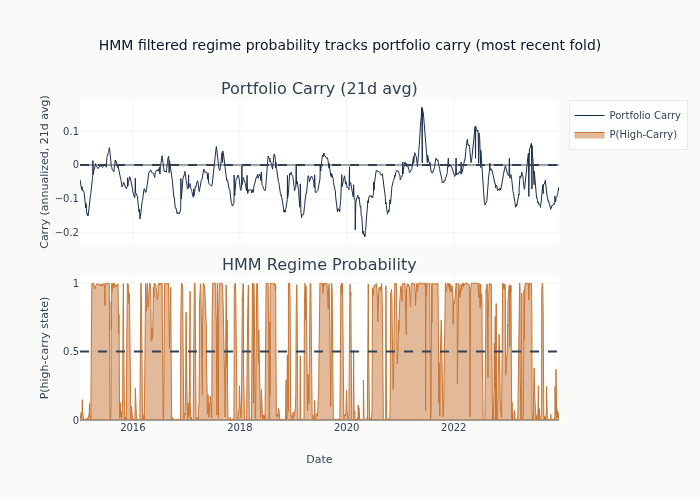

In [32]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Portfolio carry with HMM regime for the most recent fold. Folds are
# time-descending (fold 0 has the latest validation window), so fold 0 gives
# the most recent train+test span. Inner-join keeps both panels on the same
# x-range (the fold's own window) rather than trailing the full carry history.
if len(hmm_pl) > 0:
    viz_fold = hmm_pl["fold"].min()
    hmm_viz = hmm_pl.filter(pl.col("fold") == viz_fold).sort("timestamp")
    port_viz = portfolio_carry.join(
        hmm_viz.select(["timestamp", "hmm_carry_regime_prob"]), on="timestamp", how="inner"
    ).sort("timestamp")

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=["Portfolio Carry (21d avg)", "HMM Regime Probability"],
        vertical_spacing=0.1,
    )

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["portfolio_carry_21d"].to_list(),
            name="Portfolio Carry",
            line=dict(width=1, color=COLORS["slate"]),
        ),
        row=1,
        col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

    fig.add_trace(
        go.Scatter(
            x=port_viz["timestamp"].to_list(),
            y=port_viz["hmm_carry_regime_prob"].to_list(),
            name="P(High-Carry)",
            line=dict(width=1, color=COLORS["copper"]),
            fill="tozeroy",
        ),
        row=2,
        col=1,
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

    fig.update_layout(
        height=500,
        title_text="HMM filtered regime probability tracks portfolio carry (most recent fold)",
    )
    fig.update_yaxes(title_text="Carry (annualized, 21d avg)", row=1, col=1)
    fig.update_yaxes(title_text="P(high-carry state)", row=2, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.show()

In [33]:
print("\n" + "=" * 60)
print("TEMPORAL FEATURES SUMMARY")
print("=" * 60)
print(f"Total features: {len(temporal_cols)}")
print("  ARIMA: arima_carry_forecast, arima_carry_residual")
print(
    "  FFT: fft_spectral_energy, fft_dominant_period, fft_spectral_entropy, "
    "fft_energy_63d, fft_energy_126d"
)
print("  HMM: hmm_carry_regime_prob, hmm_regime_duration")
print(f"Rows: {len(temporal_features):,}")
print(f"Products: {temporal_features['product'].n_unique()}")
print(f"Folds: {temporal_features['fold'].n_unique()}")
print("=" * 60)


TEMPORAL FEATURES SUMMARY
Total features: 9
  ARIMA: arima_carry_forecast, arima_carry_residual
  FFT: fft_spectral_energy, fft_dominant_period, fft_spectral_entropy, fft_energy_63d, fft_energy_126d
  HMM: hmm_carry_regime_prob, hmm_regime_duration
Rows: 1,564,295
Products: 30
Folds: 5


## Key Takeaways

1. **ARIMA on carry z-score** captures the predictable mean-reverting
   component of term structure dynamics. Every value is an out-of-sample
   1-step-ahead walk-forward forecast (predicted from data strictly before
   each date), covering the later training dates and the test window alike.
2. **FFT spectral features** detect seasonal energy concentrations at
   quarterly (63d) and semi-annual (126d) frequencies without hardcoding
   seasonality. As a deterministic rolling transform, FFT is identical
   across folds.
3. **HMM regime detection** identifies portfolio-level carry regimes
   (favorable vs unfavorable) that condition the carry signal's effectiveness.
   Filtered (not smoothed) probabilities prevent look-ahead bias.
4. All temporal models are fitted **per fold**: parameters estimated on
   training data only, features extracted for both train+test periods.
   The `fold` column enables downstream per-fold join.

**Artifacts**: `features/model_based.parquet` (with `fold` column)

**Next**: Chapter 11+ for ML models combining Ch8 cross-sectional features
with Ch9 temporal features.